In [1]:
!pip install -q transformers librosa wandb scipy scikit-learn
!git clone https://github.com/Rudrabha/Wav2Lip.git 2>/dev/null || true
!mkdir -p Wav2Lip/checkpoints

!wget -q -nc "https://huggingface.co/Nekochu/Wav2Lip/resolve/main/wav2lip.pth" -O Wav2Lip/checkpoints/wav2lip.pth
!wget -q -nc "https://huggingface.co/Nekochu/Wav2Lip/resolve/main/lipsync_expert.pth" -O Wav2Lip/checkpoints/lipsync_expert.pth
!ls -lh Wav2Lip/checkpoints/*.pth

-rw-r--r-- 1 root root 189M Apr 21 23:56 Wav2Lip/checkpoints/lipsync_expert.pth
-rw-r--r-- 1 root root 416M Apr 21 19:53 Wav2Lip/checkpoints/wav2lip.pth


In [2]:
import os
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

'expandable_segments:True'

In [3]:
import sys
sys.path.insert(0, "/content")
sys.path.insert(0, "/content/Wav2Lip")

import gc
import json
import warnings
from pathlib import Path

import librosa
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import wandb
from torch.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

from emotion_utils import (
    DifferentiableVideoPreprocess,
    load_frozen_audio_encoder,
    load_frozen_video_encoder,
)
from models.wav2lip import Wav2Lip as Wav2LipModel

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
METADATA = "/content/processed_data/metadata.json"
WAV2LIP_CKPT = "/content/Wav2Lip/checkpoints/wav2lip.pth"
BEST_AUDIO_PATH = "/content/trained_encoders_4emotions/4emo-w2v2-er-lr3e5"
BEST_VIDEO_PATH = "/content/trained_encoders_4emotions/4emo-tsf-lr3e5-8f"
OUT_DIR = Path("/content/wav2lip_finetuned_4emo")
OUT_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDE = {0, 1, 5, 7}
REMAP = {2: 0, 3: 1, 4: 2, 6: 3}
EMOTIONS = ["happy", "sad", "angry", "disgust"]
WAV2LIP_TO_ENCODER = [2, 3, 4, 6]  # used only if encoder head_labels != len(EMOTIONS)

print(f"Device: {DEVICE}")

Device: cuda


In [4]:
IMG_SIZE = 96
MEL_STEP = 16
SR = 16000
FPS = 25

# Wav2Lip audio.py hparams — used by SyncNet (lipsync_expert.pth) for LSE-C/LSE-D.
# The trained generator is more forgiving of mel format mismatches because its
# audio_encoder was learned end-to-end; SyncNet was trained against this exact
# pipeline and degenerates to ~0 cosine similarity on any other normalization.
W2L_N_FFT = 800
W2L_HOP = 200
W2L_WIN = 800
W2L_N_MELS = 80
W2L_FMIN = 55
W2L_FMAX = 7600
W2L_MIN_LEVEL_DB = -100.0
W2L_REF_LEVEL_DB = 20.0
W2L_MAX_ABS = 4.0
W2L_PREEMPH = 0.97


def wav_to_mel(wav_path, sr=SR):
    y, _ = librosa.load(wav_path, sr=sr)
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=80, hop_length=200, win_length=800,
        fmin=55, fmax=7600)
    return librosa.power_to_db(mel, ref=np.max).astype(np.float32)


def wav_to_mel_w2l(y, sr=SR):
    """Wav2Lip audio.py mel pipeline — required by SyncNet (lipsync_expert).
    Differences vs `wav_to_mel`: pre-emphasis, magnitude (not power), fixed
    ref_level_db (not per-clip max), symmetric normalization to [-4, 4]."""
    y = np.append(y[0], y[1:] - W2L_PREEMPH * y[:-1]).astype(np.float32)
    D = librosa.stft(y=y, n_fft=W2L_N_FFT, hop_length=W2L_HOP, win_length=W2L_WIN)
    mel_basis = librosa.filters.mel(sr=sr, n_fft=W2L_N_FFT, n_mels=W2L_N_MELS,
                                     fmin=W2L_FMIN, fmax=W2L_FMAX)
    S = np.dot(mel_basis, np.abs(D))
    min_level = np.exp(W2L_MIN_LEVEL_DB / 20 * np.log(10))
    db = 20 * np.log10(np.maximum(min_level, S)) - W2L_REF_LEVEL_DB
    norm = np.clip((2 * W2L_MAX_ABS) * ((db - W2L_MIN_LEVEL_DB) / -W2L_MIN_LEVEL_DB) - W2L_MAX_ABS,
                   -W2L_MAX_ABS, W2L_MAX_ABS)
    return norm.astype(np.float32)


class Wav2LipDataset(Dataset):
    def __init__(self, metadata_path, split, T=5):
        with open(metadata_path) as f:
            data = json.load(f)
        self.samples = [s for s in data
                        if s["split"] == split and s["emotion_idx"] not in EXCLUDE]
        self.T = T

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]

        wav, sr = torchaudio.load(s["audio_path"])
        audio_1d = wav.squeeze(0)

        mel = wav_to_mel(s["audio_path"])
        mel_w2l = wav_to_mel_w2l(audio_1d.numpy(), sr=SR)  # for SyncNet eval

        frames = np.load(s["frames_path"]).astype(np.float32) / 255.0
        n_frames = frames.shape[0]

        start = np.random.randint(0, max(1, n_frames - self.T))
        face_window = frames[start:start + self.T]
        if face_window.shape[0] < self.T:
            pad = np.repeat(face_window[-1:], self.T - face_window.shape[0], axis=0)
            face_window = np.concatenate([face_window, pad], axis=0)

        mel_start = int(start / FPS * SR / 200)
        mel_end = mel_start + MEL_STEP * self.T
        mel_window = mel[:, mel_start:mel_end]
        if mel_window.shape[1] < MEL_STEP * self.T:
            mel_window = np.pad(mel_window, ((0, 0), (0, MEL_STEP * self.T - mel_window.shape[1])))

        mel_w2l_window = mel_w2l[:, mel_start:mel_end]
        if mel_w2l_window.shape[1] < MEL_STEP * self.T:
            mel_w2l_window = np.pad(
                mel_w2l_window, ((0, 0), (0, MEL_STEP * self.T - mel_w2l_window.shape[1])))

        gt = torch.from_numpy(face_window).permute(0, 3, 1, 2)
        H, W = gt.shape[2], gt.shape[3]
        if H != IMG_SIZE or W != IMG_SIZE:
            gt = F.interpolate(gt, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)

        masked = gt.clone()
        masked[:, :, IMG_SIZE // 2:, :] = 0.0

        ref_idx = np.random.randint(0, n_frames)
        ref = torch.from_numpy(frames[ref_idx]).permute(2, 0, 1).unsqueeze(0).expand(self.T, -1, -1, -1)
        if ref.shape[2] != IMG_SIZE or ref.shape[3] != IMG_SIZE:
            ref = F.interpolate(ref, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)

        face_input = torch.cat([ref, masked], dim=1)

        mel_chunks = []
        mel_w2l_chunks = []
        for t in range(self.T):
            m = mel_window[:, t * MEL_STEP:(t + 1) * MEL_STEP]
            mel_chunks.append(torch.from_numpy(m).unsqueeze(0))
            mw = mel_w2l_window[:, t * MEL_STEP:(t + 1) * MEL_STEP]
            mel_w2l_chunks.append(torch.from_numpy(mw).unsqueeze(0))
        mel_tensor = torch.stack(mel_chunks, dim=0)
        mel_syncnet_tensor = torch.stack(mel_w2l_chunks, dim=0)

        return {
            "mel": mel_tensor,
            "mel_syncnet": mel_syncnet_tensor,
            "face_input": face_input,
            "gt": gt,
            "audio": audio_1d,
            "emotion": REMAP[s["emotion_idx"]],
        }


def collate_wav2lip(batch):
    return {
        "mel": torch.stack([b["mel"] for b in batch]),
        "mel_syncnet": torch.stack([b["mel_syncnet"] for b in batch]),
        "face_input": torch.stack([b["face_input"] for b in batch]),
        "gt": torch.stack([b["gt"] for b in batch]),
        "audio": [b["audio"] for b in batch],
        "emotion": torch.tensor([b["emotion"] for b in batch]),
    }

In [5]:
def load_wav2lip(ckpt_path, device, freeze_encoders=True):
    model = Wav2LipModel()
    try:
        ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    except TypeError:
        ckpt = torch.load(ckpt_path, map_location="cpu")
    state = ckpt["state_dict"] if "state_dict" in ckpt else ckpt
    state = {k.replace("module.", ""): v for k, v in state.items()}
    model.load_state_dict(state, strict=False)
    if freeze_encoders:
        for p in model.face_encoder_blocks.parameters():
            p.requires_grad = False
        for p in model.audio_encoder.parameters():
            p.requires_grad = False
    return model.to(device)

wav2lip = load_wav2lip(WAV2LIP_CKPT, DEVICE)
total_params = sum(p.numel() for p in wav2lip.parameters())
trainable_params = sum(p.numel() for p in wav2lip.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params
print(f"Wav2Lip: {total_params/1e6:.1f}M total, {trainable_params/1e6:.1f}M trainable, {frozen_params/1e6:.1f}M frozen")

audio_enc, audio_proc = load_frozen_audio_encoder(BEST_AUDIO_PATH, DEVICE)
video_enc = load_frozen_video_encoder(BEST_VIDEO_PATH, DEVICE)
video_preprocess = DifferentiableVideoPreprocess(224).to(DEVICE)

VIDEO_ENC_FRAMES = getattr(video_enc.config, "num_frames", 8)
AUDIO_HEAD_LABELS = int(getattr(audio_enc.config, "num_labels", len(EMOTIONS)))
VIDEO_HEAD_LABELS = int(getattr(video_enc.config, "num_labels", len(EMOTIONS)))
KL_TEMPERATURE = 2.0
LABEL_SMOOTHING = 0.1
print(f"Frozen encoders loaded. Video: {VIDEO_ENC_FRAMES} frames. "
      f"Audio head labels: {AUDIO_HEAD_LABELS} | Video head labels: {VIDEO_HEAD_LABELS}")
print(f"Emotion term: CE + KL distillation (T={KL_TEMPERATURE}) — chosen by 04a ablation "
      f"(val F1=0.500, +0.112 over baseline).")


class EmotionLossComposite(nn.Module):
    """CE on video logits + KL distillation from frozen audio classifier.

    Chosen by 04a ablation among {baseline, cos-only, ce-only, ce+cos, ce+kl}.
    Base weights w_ce=0.05, w_kl=0.1 gave the highest val F1 (0.500) with
    cross-modal framing preserved. CE alone was Pareto-close (F1=0.497) but
    drops the audio pathway from the loss.
    """

    def __init__(self, w_ce=0.05, w_kl=0.10,
                 label_smoothing=LABEL_SMOOTHING, kl_temperature=KL_TEMPERATURE):
        super().__init__()
        self.w_ce = w_ce
        self.w_kl = w_kl
        self.T = kl_temperature
        self.ce = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    def forward(self, video_logits, audio_logits, labels):
        device = labels.device
        total = torch.zeros((), device=device)
        parts = {"ce": 0.0, "kl": 0.0}
        if self.w_ce > 0:
            ce = self.ce(video_logits, labels)
            total = total + self.w_ce * ce
            parts["ce"] = ce.item()
        if self.w_kl > 0:
            log_p_v = F.log_softmax(video_logits / self.T, dim=-1)
            p_a = F.softmax(audio_logits / self.T, dim=-1)
            kl = F.kl_div(log_p_v, p_a, reduction="batchmean") * (self.T ** 2)
            total = total + self.w_kl * kl
            parts["kl"] = kl.item()
        return total, parts

Wav2Lip: 36.3M total, 25.3M trainable, 11.0M frozen
Frozen encoders loaded. Video: 8 frames. Audio head labels: 4 | Video head labels: 4
Emotion term: CE + KL distillation (T=2.0) — chosen by 04a ablation (val F1=0.500, +0.112 over baseline).


In [6]:
wandb.login()

# 04a ablation winner: CE + KL distillation. Base (w_ce=0.05, w_kl=0.10) gave val
# F1=0.500 (+0.112) at recon ~+123%. The first 04 sweep showed scale=0.5 is the
# F1/recon sweet spot (val F1=0.528, recon within band); scales ≥1.0 fall out of
# the +150% recon band. This sweep zooms into the productive low-scale region
# {0.1, 0.25, 0.4, 0.5} to find the optimum more precisely.
BASE_W_CE = 0.05
BASE_W_KL = 0.10
CONFIGS = [
    {"name": "wav2lip-baseline",  "scale": 0.0},
    {"name": "wav2lip-cekl-01",   "scale": 0.10},
    {"name": "wav2lip-cekl-025",  "scale": 0.25},
    {"name": "wav2lip-cekl-04",   "scale": 0.40},
    {"name": "wav2lip-cekl-05",   "scale": 0.50},
]

CHECKPOINT_BY = "f1"  # f1 | total | recon  (baseline auto-overrides to recon below)
WARMUP_EPOCHS = 5

LR = 1e-4
EPOCHS = 70
BATCH_SIZE = 8  # B=16 OOMs on 24GB during TimeSformer backward; matches 04b
PATIENCE = 8
T_FRAMES = 5
NUM_WORKERS = 2

wandb: Currently logged in as: katrinpochtar to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [7]:
"""Fine-tuning loss (Wav2Lip face/audio encoders frozen; decoder trainable).

L = mean_t L1(gen_t, gt_t) + scale * (BASE_W_CE * CE(video_logits, labels)
        + BASE_W_KL * T**2 * KL(softmax(audio_logits / T) || softmax(video_logits / T)))

- Reconstruction: mean L1 between predicted and GT face crops per timestep.
- Emotion term:
    (a) CE on frozen TimeSformer logits applied to generated frames — direct
        emotion supervision; gradient flows back to the Wav2Lip decoder.
    (b) KL distillation from frozen HuBERT audio classifier to the video logits
        (T=2.0) — cross-modal alignment with audio as privileged signal at
        training time. Both heads share label space via WAV2LIP_TO_ENCODER remap.
- Loss family chosen by 04a ablation among {baseline, cos-only, ce-only, ce+cos,
  ce+kl}: ce+kl gave the highest val F1 (0.500 vs 0.389 baseline) with maintained
  cross-modal framing. ce+cos was strictly dominated by ce-only; cos alone
  collapses without negatives (val ΔF1=+0.016 only).
- Old SupCon variant superseded after ablation: SupCon was a defensible
  cross-modal formulation but never benchmarked head-to-head against CE+KL on
  this loss family; 04b answers that question.
- Early stopping: emo configs select by val F1; baseline by val recon (its F1
  is uninformative noise without an emotion gradient).
"""

def adapt_frames(frames, target_t):
    """Resample (B, T, C, H, W) to (B, target_t, C, H, W) via uniform index sampling."""
    B, T, C, H, W = frames.shape
    if T == target_t:
        return frames
    idx = torch.linspace(0, T - 1, target_t, device=frames.device).long()
    return frames[:, idx]


def classify_gen_video(gen_frames, batch_emotions):
    """Frozen TimeSformer logits on generated frames. Used both as the CE training
    signal and for monitoring (F1 on the same logits). Gradient flows through the
    encoder back to the Wav2Lip decoder during training."""
    gen_video = adapt_frames(gen_frames, VIDEO_ENC_FRAMES)
    pv = video_preprocess(gen_video)
    logits = video_enc(pixel_values=pv).logits
    if VIDEO_HEAD_LABELS == len(EMOTIONS):
        logits_remapped = logits
    else:
        logits_remapped = logits[:, WAV2LIP_TO_ENCODER]
    labels_dev = batch_emotions.to(DEVICE)
    return logits_remapped, labels_dev


@torch.no_grad()
def compute_audio_logits(batch_audio):
    """Frozen HuBERT classifier — KL reference distribution. No gradient."""
    sr = getattr(audio_proc, "sampling_rate", SR)
    wavs = [a.numpy() for a in batch_audio]
    enc = audio_proc(wavs, sampling_rate=sr, return_tensors="pt",
                     padding="max_length", truncation=True, max_length=int(3.0 * SR))
    kwargs = {"input_values": enc["input_values"].to(DEVICE)}
    if "attention_mask" in enc:
        kwargs["attention_mask"] = enc["attention_mask"].to(DEVICE)
    logits = audio_enc(**kwargs).logits
    if AUDIO_HEAD_LABELS == len(EMOTIONS):
        return logits
    return logits[:, WAV2LIP_TO_ENCODER]


def train_one_epoch(model, loader, optimizer, scaler, loss_fn):
    model.train()
    agg = {"recon": 0.0, "emo": 0.0, "total": 0.0, "ce": 0.0, "kl": 0.0}

    for batch in tqdm(loader, leave=False):
        mel = batch["mel"].to(DEVICE)
        face_in = batch["face_input"].to(DEVICE)
        gt = batch["gt"].to(DEVICE)
        labels = batch["emotion"].to(DEVICE)
        T = mel.shape[1]

        optimizer.zero_grad(set_to_none=True)
        with autocast("cuda", enabled=DEVICE == "cuda"):
            gens = []
            recon = 0.0
            for t in range(T):
                g = model(mel[:, t], face_in[:, t])
                recon = recon + F.l1_loss(g, gt[:, t])
                gens.append(g)
            recon = recon / T

            emo = torch.zeros((), device=DEVICE)
            parts = {"ce": 0.0, "kl": 0.0}
            if loss_fn.w_ce + loss_fn.w_kl > 0:
                gen_video = torch.stack(gens, dim=1)
                v_logits, _ = classify_gen_video(gen_video, batch["emotion"])
                a_logits = compute_audio_logits(batch["audio"]) if loss_fn.w_kl > 0 else None
                emo, parts = loss_fn(v_logits, a_logits, labels)

            loss = recon + emo

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        params = list(filter(lambda p: p.requires_grad, model.parameters()))
        nn.utils.clip_grad_norm_(params, 1.0)
        scaler.step(optimizer)
        scaler.update()

        agg["recon"] += recon.item()
        agg["emo"] += emo.item() if isinstance(emo, torch.Tensor) else emo
        agg["total"] += loss.item()
        for k in ("ce", "kl"):
            agg[k] += parts[k]

    n = max(len(loader), 1)
    return {k: v / n for k, v in agg.items()}


@torch.no_grad()
def evaluate(model, loader, loss_fn):
    """Recon + emotion loss; classifier accuracy + F1 for monitoring."""
    model.eval()
    total_recon, total_emo, total_loss = 0.0, 0.0, 0.0
    correct, total_samples = 0, 0
    all_preds, all_labels = [], []
    correct_by_emo = {e: 0 for e in range(len(EMOTIONS))}
    total_by_emo = {e: 0 for e in range(len(EMOTIONS))}

    for batch in tqdm(loader, leave=False):
        mel = batch["mel"].to(DEVICE)
        face_in = batch["face_input"].to(DEVICE)
        gt = batch["gt"].to(DEVICE)
        labels = batch["emotion"].to(DEVICE)
        T = mel.shape[1]

        with autocast("cuda", enabled=DEVICE == "cuda"):
            gens = []
            recon = 0.0
            for t in range(T):
                g = model(mel[:, t], face_in[:, t])
                recon = recon + F.l1_loss(g, gt[:, t])
                gens.append(g)
            recon = recon / T

            gen_video = torch.stack(gens, dim=1)
            v_logits, enc_labels = classify_gen_video(gen_video, batch["emotion"])
            a_logits = compute_audio_logits(batch["audio"]) if loss_fn.w_kl > 0 else None
            if loss_fn.w_ce + loss_fn.w_kl > 0:
                emo, _ = loss_fn(v_logits, a_logits, labels)
            else:
                emo = torch.zeros((), device=DEVICE)
            loss = recon + emo

        preds = v_logits.argmax(dim=1)
        correct += (preds == enc_labels).sum().item()
        total_samples += enc_labels.shape[0]
        for j in range(enc_labels.shape[0]):
            e = int(enc_labels[j].item())
            p = int(preds[j].item())
            all_labels.append(e)
            all_preds.append(p)
            total_by_emo[e] += 1
            if p == e:
                correct_by_emo[e] += 1

        total_recon += recon.item()
        total_emo += emo.item() if isinstance(emo, torch.Tensor) else emo
        total_loss += loss.item()

    n = max(len(loader), 1)

    by_emotion = {
        e: correct_by_emo[e] / total_by_emo[e] if total_by_emo[e] > 0 else 0.0
        for e in range(len(EMOTIONS))
    }

    per_emotion_prf = {}
    emo_f1 = 0.0
    if all_preds:
        from sklearn.metrics import precision_recall_fscore_support, f1_score
        prec, rec, f1, sup = precision_recall_fscore_support(
            all_labels, all_preds, labels=list(range(len(EMOTIONS))), zero_division=0,
        )
        emo_f1 = float(f1_score(all_labels, all_preds, labels=list(range(len(EMOTIONS))), average="macro", zero_division=0))
        for e in range(len(EMOTIONS)):
            per_emotion_prf[e] = {"precision": float(prec[e]), "recall": float(rec[e]), "f1": float(f1[e]), "support": int(sup[e])}
    else:
        for e in range(len(EMOTIONS)):
            per_emotion_prf[e] = {"precision": 0.0, "recall": 0.0, "f1": 0.0, "support": 0}

    return {
        "recon": total_recon / n,
        "emotion": total_emo / n,
        "total": total_loss / n,
        "emo_accuracy": correct / total_samples if total_samples > 0 else 0,
        "f1": emo_f1,
        "by_emotion": by_emotion,
        "per_emotion_prf": per_emotion_prf,
    }

In [8]:
train_ds = Wav2LipDataset(METADATA, "train", T=T_FRAMES)
val_ds = Wav2LipDataset(METADATA, "val", T=T_FRAMES)
test_ds = Wav2LipDataset(METADATA, "test", T=T_FRAMES)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          collate_fn=collate_wav2lip)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True,
                        collate_fn=collate_wav2lip)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True,
                         collate_fn=collate_wav2lip)
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

all_results = []

for cfg in CONFIGS:
    name = cfg["name"]
    scale = cfg["scale"]
    w_ce = BASE_W_CE * scale
    w_kl = BASE_W_KL * scale
    # Baseline has no emotion gradient → its F1 is noise; checkpoint by recon.
    select_by = "recon" if scale == 0.0 else CHECKPOINT_BY
    print(f"\n{'='*60}\n{name} (scale={scale}, w_ce={w_ce}, w_kl={w_kl}, "
          f"checkpoint_by={select_by})\n{'='*60}")

    wandb.init(project="uncanny-valley-wav2lip-4emo", name=name,
               config={**cfg, "w_ce": w_ce, "w_kl": w_kl,
                       "lr": LR, "epochs": EPOCHS,
                       "checkpoint_by": select_by, "warmup_epochs": WARMUP_EPOCHS,
                       "kl_temperature": KL_TEMPERATURE,
                       "label_smoothing": LABEL_SMOOTHING}, reinit=True)

    model = load_wav2lip(WAV2LIP_CKPT, DEVICE, freeze_encoders=True)
    loss_fn = EmotionLossComposite(w_ce=w_ce, w_kl=w_kl)
    opt_params = list(filter(lambda p: p.requires_grad, model.parameters()))
    optimizer = torch.optim.AdamW(opt_params, lr=LR)
    scaler = GradScaler(enabled=DEVICE == "cuda")

    best_total, best_recon = float("inf"), float("inf")
    best_acc, best_f1 = 0.0, 0.0
    best_ckpt_score = float("inf") if select_by in ("recon", "total") else -float("inf")
    patience_cnt = 0
    save_path = OUT_DIR / name

    for epoch in range(EPOCHS):
        warmup = min(1.0, (epoch + 1) / WARMUP_EPOCHS) if WARMUP_EPOCHS > 0 else 1.0
        loss_fn.w_ce = w_ce * warmup
        loss_fn.w_kl = w_kl * warmup
        t = train_one_epoch(model, train_loader, optimizer, scaler, loss_fn)

        loss_fn.w_ce = w_ce
        loss_fn.w_kl = w_kl
        v = evaluate(model, val_loader, loss_fn)

        wandb.log({
            "epoch": epoch + 1,
            "train/recon": t["recon"], "train/emo": t["emo"], "train/total": t["total"],
            "train/ce": t["ce"], "train/kl": t["kl"],
            "val/recon": v["recon"], "val/emotion": v["emotion"], "val/total": v["total"],
            "val/emo_accuracy": v["emo_accuracy"],
            "val/f1": v["f1"],
        })

        prf = v["per_emotion_prf"]
        print(f"  [{epoch+1:2d}/{EPOCHS}] "
              f"t_loss={t['total']:.4f} t_emo={t['emo']:.4f} (ce={t['ce']:.3f} kl={t['kl']:.3f}) "
              f"v_loss={v['total']:.4f} v_recon={v['recon']:.4f} acc={v['emo_accuracy']:.3f} F1={v['f1']:.3f}")
        print(
            "    val by_emo: "
            + "  ".join(
                f"{EMOTIONS[e]}(P={prf[e]['precision']:.2f} R={prf[e]['recall']:.2f} F1={prf[e]['f1']:.2f})"
                for e in range(len(EMOTIONS))
            )
        )

        if v["total"] < best_total:
            best_total = v["total"]
        if v["recon"] < best_recon:
            best_recon = v["recon"]
        if v["emo_accuracy"] > best_acc:
            best_acc = v["emo_accuracy"]
        if v["f1"] > best_f1:
            best_f1 = v["f1"]

        if select_by == "recon":
            score_now = v["recon"]; is_better = score_now < best_ckpt_score
        elif select_by == "total":
            score_now = v["total"]; is_better = score_now < best_ckpt_score
        else:  # f1
            score_now = v["f1"]; is_better = score_now > best_ckpt_score

        if is_better:
            best_ckpt_score = score_now
            save_path.mkdir(parents=True, exist_ok=True)
            torch.save(model.state_dict(), save_path / "wav2lip.pth")
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f"  Early stopping at epoch {epoch+1} (no {select_by} improvement for {PATIENCE} epochs)")
                break

    wandb.finish()
    del model, optimizer, scaler, loss_fn
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()
    all_results.append({
        "name": name,
        "scale": scale,
        "w_ce": w_ce,
        "w_kl": w_kl,
        "checkpoint_by": select_by,
        "best_val": best_ckpt_score,
        "best_recon": best_recon,
        "best_emo_accuracy": best_acc,
        "best_f1": best_f1,
        "best_total": best_total,
    })
    print(
        f"  Saved checkpoint ({select_by}) score={best_ckpt_score:.4f} | "
        f"recon={best_recon:.4f} emo_acc={best_acc:.3f} F1={best_f1:.3f} total={best_total:.4f} -> {save_path}"
    )

Train: 544, Val: 96, Test: 96

wav2lip-baseline (scale=0.0, w_ce=0.0, w_kl=0.0, checkpoint_by=recon)


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


  [ 1/70] t_loss=0.3864 t_emo=0.0000 (ce=0.000 kl=0.000) v_loss=0.3603 v_recon=0.3603 acc=0.344 F1=0.272
    val by_emo: happy(P=0.40 R=0.75 F1=0.52)  sad(P=0.27 R=0.50 F1=0.35)  angry(P=1.00 R=0.04 F1=0.08)  disgust(P=0.40 R=0.08 F1=0.14)


  [ 2/70] t_loss=0.3410 t_emo=0.0000 (ce=0.000 kl=0.000) v_loss=0.3121 v_recon=0.3121 acc=0.302 F1=0.202
    val by_emo: happy(P=0.28 R=0.92 F1=0.43)  sad(P=0.38 R=0.25 F1=0.30)  angry(P=1.00 R=0.04 F1=0.08)  disgust(P=0.00 R=0.00 F1=0.00)


  [ 3/70] t_loss=0.2909 t_emo=0.0000 (ce=0.000 kl=0.000) v_loss=0.2556 v_recon=0.2556 acc=0.312 F1=0.216
    val by_emo: happy(P=0.29 R=1.00 F1=0.45)  sad(P=0.29 R=0.08 F1=0.13)  angry(P=0.60 R=0.12 F1=0.21)  disgust(P=0.50 R=0.04 F1=0.08)


...

  [23/70] t_loss=0.1771 t_emo=0.0694 (ce=0.715 kl=1.031) v_loss=0.1973 v_recon=0.1022 acc=0.688 F1=0.684
    val by_emo: happy(P=0.85 R=0.92 F1=0.88)  sad(P=0.52 R=0.50 F1=0.51)  angry(P=1.00 R=0.50 F1=0.67)  disgust(P=0.57 R=0.83 F1=0.68)


  [24/70] t_loss=0.1713 t_emo=0.0670 (ce=0.704 kl=0.988) v_loss=0.1951 v_recon=0.0958 acc=0.708 F1=0.712
    val by_emo: happy(P=0.92 R=0.96 F1=0.94)  sad(P=0.52 R=0.54 F1=0.53)  angry(P=0.94 R=0.62 F1=0.75)  disgust(P=0.57 R=0.71 F1=0.63)


  [25/70] t_loss=0.1672 t_emo=0.0665 (ce=0.685 kl=0.986) v_loss=0.1940 v_recon=0.0925 acc=0.625 F1=0.621
    val by_emo: happy(P=0.90 R=0.79 F1=0.84)  sad(P=0.47 R=0.33 F1=0.39)  angry(P=0.70 R=0.58 F1=0.64)  disgust(P=0.50 R=0.79 F1=0.61)
  Early stopping at epoch 25 (no f1 improvement for 8 epochs)


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train/ce,██▇▇▇▇▆▆▅▅▅▄▄▃▃▃▂▂▂▂▂▂▁▁▁
train/emo,▁▃▅▆███▇▇▇▇▆▆▅▅▅▄▅▅▄▄▄▄▄▄
train/kl,███▇▇▇▆▆▅▅▅▄▄▃▃▃▂▂▂▂▁▂▁▁▁
train/recon,█▇▆▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁
train/total,██▇▇▇▇▆▅▅▅▄▄▄▃▃▃▂▂▂▂▂▂▁▁▁
val/emo_accuracy,▁▃▄▄▄▄▅▅▅▄▆▆▆▇▆▇█▆▇▇▇▇▇█▇
val/emotion,█▇▆▆▆▆▅▆▅▆▅▄▃▂▄▂▃▄▂▁▃▃▂▃▃
val/f1,▁▂▄▄▄▅▅▅▅▄▅▆▆▇▆▇█▆▇█▇▇▇█▇
val/recon,█▇▆▅▅▅▄▄▃▃▃▃▂▃▂▂▂▂▂▂▂▁▁▁▁
+1,...


  Saved checkpoint (f1) score=0.7365 | recon=0.0925 emo_acc=0.729 F1=0.736 total=0.1940 -> /content/wav2lip_finetuned_4emo/wav2lip-cekl-05


Selection rule: maximize F1 among models within +150% of baseline recon (baseline=0.0382, band ≤ 0.0954). Final H1 verdict uses test LSE-C, not val L1.
            name  scale   w_ce  w_kl checkpoint_by  best_recon  best_emo_accuracy  best_f1  best_total  within_recon_band
 wav2lip-cekl-01   0.10 0.0050 0.010            f1    0.048251           0.739583 0.742119    0.069489               True
 wav2lip-cekl-04   0.40 0.0200 0.040            f1    0.061501           0.739583 0.739099    0.134252               True
 wav2lip-cekl-05   0.50 0.0250 0.050            f1    0.092536           0.729167 0.736491    0.194042               True
wav2lip-cekl-025   0.25 0.0125 0.025            f1    0.089393           0.687500 0.691431    0.138111               True
wav2lip-baseline   0.00 0.0000 0.000         recon    0.038165           0.635417 0.623953    0.038165               True


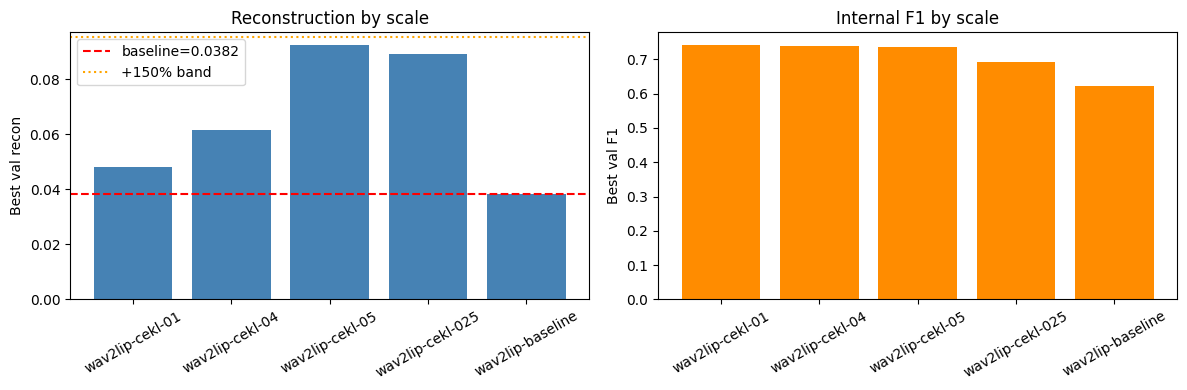

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(all_results)
baseline_recon = df.loc[df["scale"] == 0.0, "best_recon"].iloc[0]
# CE+KL inherently degrades L1 recon (~+80–120% at scale=1.0 in 04b). H1 success
# is judged by LSE-C on test split (≤ ±2% allowed), not val L1; the band here
# only filters runs that are catastrophically bad on val.
RECON_BAND_FRAC = 1.5  # accept up to +150% recon vs baseline
recon_band = RECON_BAND_FRAC * baseline_recon

df["within_recon_band"] = df["best_recon"] <= (baseline_recon + recon_band)
df["selection_score"] = df["best_f1"].where(df["within_recon_band"], -1.0)

df = df.sort_values(["selection_score", "best_recon", "best_f1", "best_total"],
                    ascending=[False, True, False, True]).reset_index(drop=True)

print(
    f"Selection rule: maximize F1 among models within +{int(RECON_BAND_FRAC*100)}% of baseline recon "
    f"(baseline={baseline_recon:.4f}, band ≤ {baseline_recon + recon_band:.4f}). "
    f"Final H1 verdict uses test LSE-C, not val L1."
)
print(df[[
    "name", "scale", "w_ce", "w_kl", "checkpoint_by",
    "best_recon", "best_emo_accuracy", "best_f1", "best_total", "within_recon_band"
]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(df["name"], df["best_recon"], color="steelblue")
axes[0].axhline(baseline_recon, color="red", ls="--", label=f"baseline={baseline_recon:.4f}")
axes[0].axhline(baseline_recon + recon_band, color="orange", ls=":",
                label=f"+{int(RECON_BAND_FRAC*100)}% band")
axes[0].set_ylabel("Best val recon")
axes[0].set_title("Reconstruction by scale")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend()

axes[1].bar(df["name"], df["best_f1"], color="darkorange")
axes[1].set_ylabel("Best val F1")
axes[1].set_title("Internal F1 by scale")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Baseline: wav2lip-baseline  |  Best emotion-aware: wav2lip-cekl-01
Evaluating baseline (L1 only)...


Evaluating best (L1 + emotion loss)...


  SyncNet sanity OK: baseline LSE-C=0.2420

=== Statistical significance ===
L1 recon  — paired t-test: t=-5.3068, p=7.2876e-07
L1 recon  — Wilcoxon signed-rank: W=346.0, p=4.3937e-13
Emo acc   — McNemar's test: χ²=1.8846, p=1.6981e-01  (n01=9, n10=17)
LSE-C     — paired t-test: t=0.5099, p=6.1130e-01

=== Success criteria ===
  ΔF1 = +0.1069 (≥ +0.10 required)   McNemar p = 1.6981e-01 (< 0.05 required)  → FAIL
  ΔLSE-C = -6.13% (≤ ±2% required)  paired t p = 6.1130e-01 (< 0.05 required)  → FAIL
    LSE-C change exceeds 2% but is not statistically significant

=== Baseline vs Best comparison ===
      metric  wav2lip-baseline  wav2lip-cekl-01      p-value     delta
    L1 recon          0.046744         0.071982 4.393721e-13  0.025238
emo_accuracy          0.635417         0.718750 1.698105e-01  0.083333
          F1          0.611127         0.717979 1.698105e-01  0.106853
     LSE-C ↑          0.241960         0.227133 6.113037e-01 -0.014827
     LSE-D ↓          0.758040         0.7

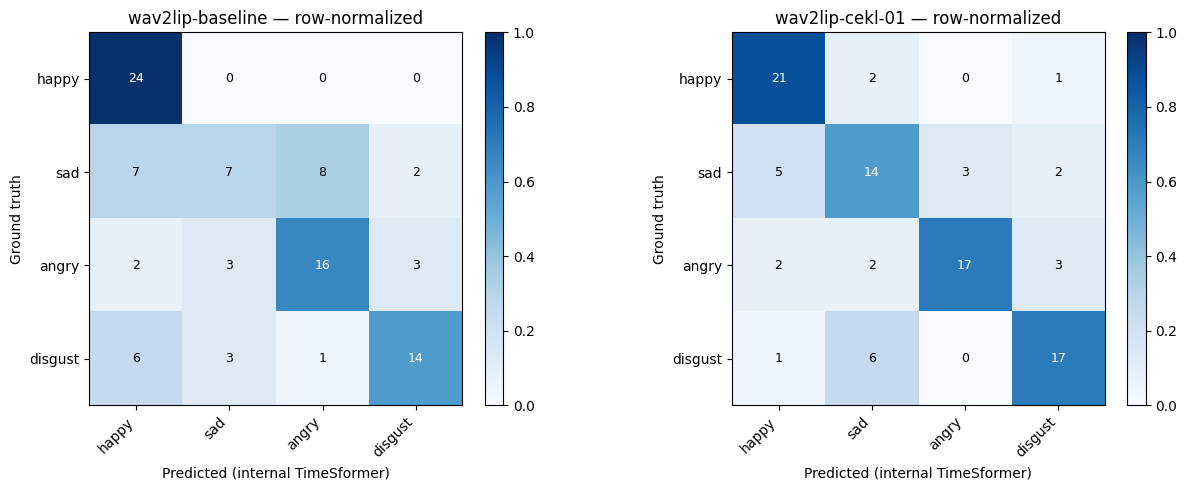

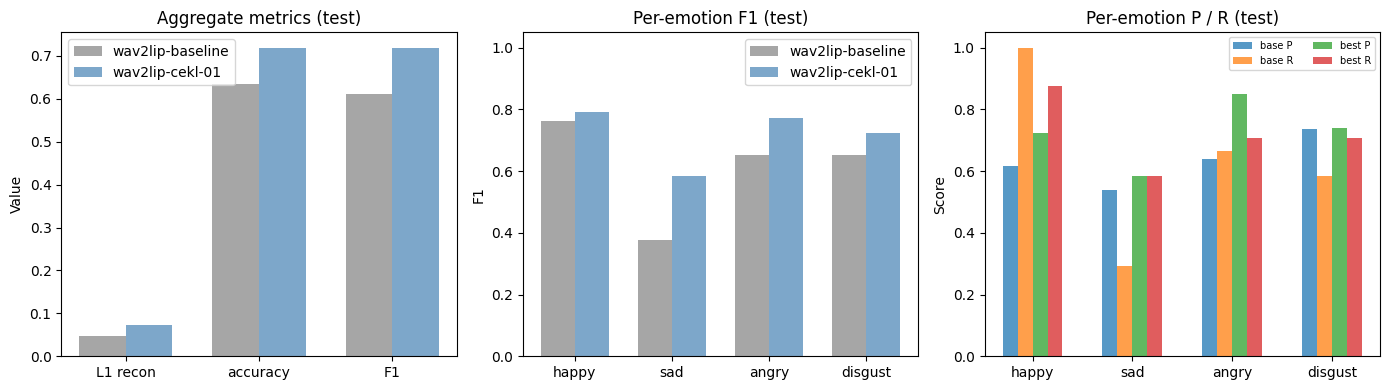


=== Side-by-side sample frames (one per emotion) ===


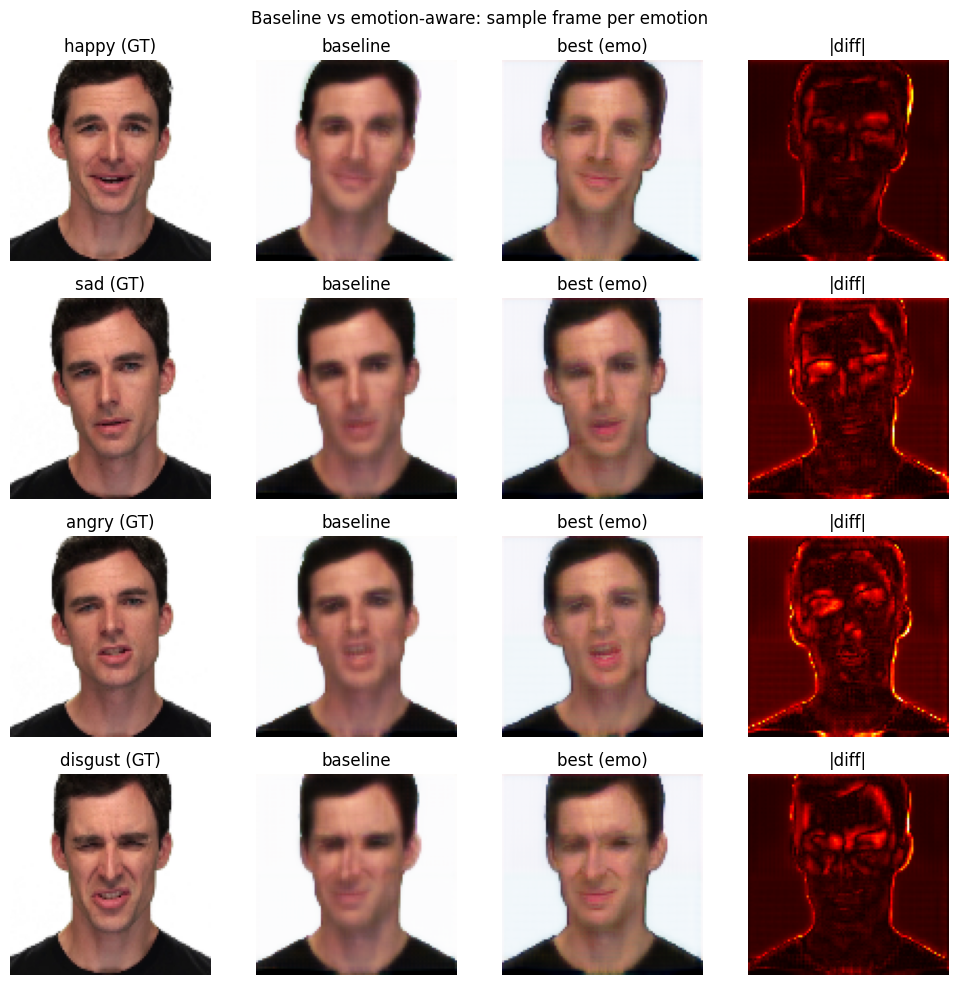

In [10]:
"""Baseline vs Best: paired comparison on TEST split (held-out)"""
from scipy import stats
from sklearn.metrics import precision_recall_fscore_support, f1_score, confusion_matrix
import subprocess


# ── SyncNet (Wav2Lip lipsync expert) for LSE-C / LSE-D ──────────────

SYNCNET_CKPT = Path("/content/Wav2Lip/checkpoints/lipsync_expert.pth")
SYNCNET_URL = "https://huggingface.co/Nekochu/Wav2Lip/resolve/main/lipsync_expert.pth"
SYNCNET_T = 5


class _SyncNetConv(nn.Module):
    def __init__(self, cin, cout, kernel_size, stride, padding, residual=False):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(cin, cout, kernel_size, stride, padding),
            nn.BatchNorm2d(cout),
        )
        self.act = nn.ReLU()
        self.residual = residual

    def forward(self, x):
        out = self.conv_block(x)
        if self.residual:
            out += x
        return self.act(out)


class SyncNet_color(nn.Module):
    def __init__(self):
        super().__init__()
        self.face_encoder = nn.Sequential(
            _SyncNetConv(15, 32, (7, 7), 1, 3),
            _SyncNetConv(32, 64, 5, (1, 2), 1),
            _SyncNetConv(64, 64, 3, 1, 1, residual=True),
            _SyncNetConv(64, 64, 3, 1, 1, residual=True),
            _SyncNetConv(64, 128, 3, 2, 1),
            _SyncNetConv(128, 128, 3, 1, 1, residual=True),
            _SyncNetConv(128, 128, 3, 1, 1, residual=True),
            _SyncNetConv(128, 128, 3, 1, 1, residual=True),
            _SyncNetConv(128, 256, 3, 2, 1),
            _SyncNetConv(256, 256, 3, 1, 1, residual=True),
            _SyncNetConv(256, 256, 3, 1, 1, residual=True),
            _SyncNetConv(256, 512, 3, 2, 1),
            _SyncNetConv(512, 512, 3, 1, 1, residual=True),
            _SyncNetConv(512, 512, 3, 1, 1, residual=True),
            _SyncNetConv(512, 512, 3, 2, 1),
            _SyncNetConv(512, 512, 3, 1, 0),
            _SyncNetConv(512, 512, 1, 1, 0),
        )
        self.audio_encoder = nn.Sequential(
            _SyncNetConv(1, 32, 3, 1, 1),
            _SyncNetConv(32, 32, 3, 1, 1, residual=True),
            _SyncNetConv(32, 32, 3, 1, 1, residual=True),
            _SyncNetConv(32, 64, 3, (3, 1), 1),
            _SyncNetConv(64, 64, 3, 1, 1, residual=True),
            _SyncNetConv(64, 64, 3, 1, 1, residual=True),
            _SyncNetConv(64, 128, 3, 3, 1),
            _SyncNetConv(128, 128, 3, 1, 1, residual=True),
            _SyncNetConv(128, 128, 3, 1, 1, residual=True),
            _SyncNetConv(128, 256, 3, (3, 2), 1),
            _SyncNetConv(256, 256, 3, 1, 1, residual=True),
            _SyncNetConv(256, 256, 3, 1, 1, residual=True),
            _SyncNetConv(256, 512, 3, 1, 0),
            _SyncNetConv(512, 512, 1, 1, 0),
        )

    def forward(self, audio_sequences, face_sequences):
        face_embedding = self.face_encoder(face_sequences)
        audio_embedding = self.audio_encoder(audio_sequences)
        audio_embedding = audio_embedding.view(audio_embedding.size(0), -1)
        face_embedding = face_embedding.view(face_embedding.size(0), -1)
        audio_embedding = F.normalize(audio_embedding, p=2, dim=1)
        face_embedding = F.normalize(face_embedding, p=2, dim=1)
        return audio_embedding, face_embedding


def load_syncnet(ckpt_path, device):
    ckpt_path = Path(ckpt_path)
    ckpt_path.parent.mkdir(parents=True, exist_ok=True)

    def _load_ckpt(path):
        try:
            return torch.load(path, map_location=device, weights_only=False)
        except TypeError:
            return torch.load(path, map_location=device)

    if not ckpt_path.exists():
        print(f"Downloading SyncNet checkpoint -> {ckpt_path}")
        subprocess.check_call(["wget", "-q", SYNCNET_URL, "-O", str(ckpt_path)])

    model = SyncNet_color()
    try:
        ckpt = _load_ckpt(ckpt_path)
        sd = ckpt.get("state_dict", ckpt)
        sd = {k.replace("module.", ""): v for k, v in sd.items()}
        model.load_state_dict(sd, strict=True)
    except RuntimeError:
        print("SyncNet checkpoint mismatch. Re-downloading official lipsync_expert.pth...")
        subprocess.check_call(["wget", "-q", SYNCNET_URL, "-O", str(ckpt_path)])
        ckpt = _load_ckpt(ckpt_path)
        sd = ckpt.get("state_dict", ckpt)
        sd = {k.replace("module.", ""): v for k, v in sd.items()}
        model.load_state_dict(sd, strict=True)

    model.to(device).eval()
    return model

baseline_name = df.loc[df["scale"] == 0.0, "name"].iloc[0]
best_emo_df = df.loc[df["scale"] > 0.0]
best_name = best_emo_df.iloc[0]["name"]
print(f"Baseline: {baseline_name}  |  Best emotion-aware: {best_name}")

def eval_model_per_sample(model, loader, syncnet=None):
    """Per-sample L1, correctness, F1, per-emotion P/R/F1, and LSE-C/D."""
    model.eval()
    sample_recons = []
    sample_correct = []
    all_labels = []
    all_preds = []
    correct_by_emo = {e: 0 for e in range(len(EMOTIONS))}
    total_by_emo = {e: 0 for e in range(len(EMOTIONS))}
    lse_c_vals = []
    lse_d_vals = []
    with torch.no_grad():
        for batch in tqdm(loader, leave=False, desc="Eval"):
            mel = batch["mel"].to(DEVICE)
            mel_sync = batch["mel_syncnet"].to(DEVICE)
            face_in = batch["face_input"].to(DEVICE)
            gt = batch["gt"].to(DEVICE)
            B, T = mel.shape[0], mel.shape[1]
            all_gen = []
            per_sample_recon = torch.zeros(B, device=DEVICE)
            for t in range(T):
                gen = model(mel[:, t], face_in[:, t])
                all_gen.append(gen)
                per_sample_recon += F.l1_loss(gen, gt[:, t], reduction="none").mean(dim=(1, 2, 3))
            per_sample_recon /= T
            sample_recons.extend(per_sample_recon.cpu().tolist())

            gen_video = torch.stack(all_gen, dim=1)
            logits, enc_labels = classify_gen_video(gen_video, batch["emotion"])
            preds = logits.argmax(dim=1)
            hits = (preds == enc_labels).cpu().tolist()
            sample_correct.extend(hits)
            for i, e in enumerate(batch["emotion"].tolist()):
                p = int(preds[i].item())
                all_labels.append(e)
                all_preds.append(p)
                total_by_emo[e] += 1
                if hits[i]:
                    correct_by_emo[e] += 1

            if syncnet is not None and T >= SYNCNET_T:
                gen_stack = torch.stack(all_gen, dim=1)  # (B, T, 3, 96, 96)
                for b in range(B):
                    for t0 in range(T - SYNCNET_T + 1):
                        lips = gen_stack[b, t0:t0 + SYNCNET_T, :, 48:, :]  # (5, 3, 48, 96)
                        vid_in = lips.reshape(1, 15, 48, 96)
                        # Wav2Lip-format mel for SyncNet (see W2L_* constants in cell 3)
                        aud_in = mel_sync[b, t0 + SYNCNET_T // 2].unsqueeze(0)  # (1, 1, 80, 16)
                        a_emb, v_emb = syncnet(aud_in, vid_in)
                        cs = F.cosine_similarity(a_emb, v_emb).item()
                        lse_c_vals.append(cs)
                        lse_d_vals.append(1.0 - cs)

    total_correct = sum(correct_by_emo.values())
    total_samples = sum(total_by_emo.values())

    per_emotion_prf = {}
    emo_f1 = 0.0
    if all_labels:
        prec, rec, f1, sup = precision_recall_fscore_support(
            all_labels, all_preds, labels=list(range(len(EMOTIONS))), zero_division=0,
        )
        emo_f1 = float(f1_score(all_labels, all_preds, labels=list(range(len(EMOTIONS))), average="macro", zero_division=0))
        for e in range(len(EMOTIONS)):
            per_emotion_prf[e] = {"precision": float(prec[e]), "recall": float(rec[e]), "f1": float(f1[e]), "support": int(sup[e])}
    else:
        for e in range(len(EMOTIONS)):
            per_emotion_prf[e] = {"precision": 0.0, "recall": 0.0, "f1": 0.0, "support": 0}

    return {
        "recon": np.mean(sample_recons),
        "recon_samples": np.array(sample_recons),
        "emo_accuracy": total_correct / total_samples if total_samples > 0 else 0,
        "f1": emo_f1,
        "correct": np.array(sample_correct, dtype=bool),
        "labels": np.array(all_labels, dtype=int),
        "preds": np.array(all_preds, dtype=int),
        "by_emotion": {
            e: correct_by_emo[e] / total_by_emo[e] if total_by_emo[e] > 0 else 0
            for e in range(len(EMOTIONS))
        },
        "per_emotion_prf": per_emotion_prf,
        "lse_c": float(np.mean(lse_c_vals)) if lse_c_vals else float("nan"),
        "lse_d": float(np.mean(lse_d_vals)) if lse_d_vals else float("nan"),
        "lse_c_samples": np.array(lse_c_vals, dtype=np.float64),
    }


def _load_state_dict(path):
    try:
        return torch.load(path, map_location=DEVICE, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=DEVICE)

baseline = load_wav2lip(WAV2LIP_CKPT, DEVICE)
baseline.load_state_dict(_load_state_dict(OUT_DIR / baseline_name / "wav2lip.pth"))

best = load_wav2lip(WAV2LIP_CKPT, DEVICE)
best.load_state_dict(_load_state_dict(OUT_DIR / best_name / "wav2lip.pth"))

try:
    syncnet = load_syncnet(SYNCNET_CKPT, DEVICE)
except Exception as exc:
    syncnet = None
    print(f"Warning: failed to load SyncNet ({exc}) — LSE-C/LSE-D will be NaN")

print("Evaluating baseline (L1 only)...")
baseline_metrics = eval_model_per_sample(baseline, test_loader, syncnet=syncnet)
print("Evaluating best (L1 + emotion loss)...")
best_metrics = eval_model_per_sample(best, test_loader, syncnet=syncnet)

# Sanity-check SyncNet output: random embeddings → cosine ≈ 0; trained SyncNet on
# real Wav2Lip output gives baseline LSE-C in the 0.2–0.5 range. If it's < 0.05,
# the mel format is wrong (see wav_to_mel_w2l in cell 3).
if syncnet is not None and not np.isnan(baseline_metrics["lse_c"]):
    if abs(baseline_metrics["lse_c"]) < 0.05:
        print(f"  WARNING: baseline LSE-C={baseline_metrics['lse_c']:.4f} is near zero — "
              f"SyncNet may be receiving incorrectly normalized inputs.")
    else:
        print(f"  SyncNet sanity OK: baseline LSE-C={baseline_metrics['lse_c']:.4f}")

# --- Statistical significance ---
# L1 reconstruction: paired t-test & Wilcoxon signed-rank
_br = baseline_metrics["recon_samples"]
_bst = best_metrics["recon_samples"]
_n = min(len(_br), len(_bst))
_br, _bst = _br[:_n], _bst[:_n]
if _n < 2:
    t_stat, p_ttest = float("nan"), float("nan")
    w_stat, p_wilcox = float("nan"), float("nan")
else:
    t_stat, p_ttest = stats.ttest_rel(_br, _bst)
    try:
        w_stat, p_wilcox = stats.wilcoxon(_br, _bst)
    except ValueError:
        w_stat, p_wilcox = float("nan"), float("nan")

# Emotion accuracy: McNemar's test on paired correct/incorrect (same prefix length as L1)
b_ok = baseline_metrics["correct"][:_n]
e_ok = best_metrics["correct"][:_n]
n01 = int((b_ok & ~e_ok).sum())  # baseline correct, best wrong
n10 = int((~b_ok & e_ok).sum())  # baseline wrong, best correct
mcnemar_chi2 = (abs(n01 - n10) - 1) ** 2 / max(n01 + n10, 1)
p_mcnemar = 1 - stats.chi2.cdf(mcnemar_chi2, df=1) if (n01 + n10) > 0 else 1.0

# LSE-C: paired t-test on per-window cosine similarities
_lse_b = baseline_metrics["lse_c_samples"]
_lse_e = best_metrics["lse_c_samples"]
_lse_n = min(len(_lse_b), len(_lse_e))
if _lse_n >= 2:
    t_lse, p_lse = stats.ttest_rel(_lse_b[:_lse_n], _lse_e[:_lse_n])
else:
    t_lse, p_lse = float("nan"), float("nan")

# ΔF1 and ΔLSE-C
delta_f1 = best_metrics["f1"] - baseline_metrics["f1"]
delta_lse_c = best_metrics["lse_c"] - baseline_metrics["lse_c"]
delta_lse_c_pct = (delta_lse_c / abs(baseline_metrics["lse_c"]) * 100) if baseline_metrics["lse_c"] != 0 and not np.isnan(baseline_metrics["lse_c"]) else float("nan")

print("\n=== Statistical significance ===")
print(f"L1 recon  — paired t-test: t={t_stat:.4f}, p={p_ttest:.4e}")
print(f"L1 recon  — Wilcoxon signed-rank: W={w_stat:.1f}, p={p_wilcox:.4e}")
print(f"Emo acc   — McNemar's test: χ²={mcnemar_chi2:.4f}, p={p_mcnemar:.4e}"
      f"  (n01={n01}, n10={n10})")
print(f"LSE-C     — paired t-test: t={t_lse:.4f}, p={p_lse:.4e}")

# --- Success criteria ---
# LSE-C must be a valid number AND |Δ| ≤ 2%; NaN no longer auto-passes.
f1_pass = delta_f1 >= 0.10 and p_mcnemar < 0.05
lse_pass = (not np.isnan(delta_lse_c_pct)) and abs(delta_lse_c_pct) <= 2.0
lse_sig = (not np.isnan(p_lse)) and p_lse < 0.05

print("\n=== Success criteria ===")
print(f"  ΔF1 = {delta_f1:+.4f} (≥ +0.10 required)   McNemar p = {p_mcnemar:.4e} (< 0.05 required)  → {'PASS' if f1_pass else 'FAIL'}")
print(f"  ΔLSE-C = {delta_lse_c_pct:+.2f}% (≤ ±2% required)  paired t p = {p_lse:.4e} (< 0.05 required)  → {'PASS' if lse_pass else 'FAIL'}")
if np.isnan(delta_lse_c_pct):
    print("    LSE-C is NaN — SyncNet pipeline broken; H1 cannot be verified on lip sync.")
elif lse_sig and not lse_pass:
    print("    LSE-C degradation is statistically significant — lip sync quality affected")
elif not lse_sig and not lse_pass:
    print("    LSE-C change exceeds 2% but is not statistically significant")

# --- Summary table ---
cmp = pd.DataFrame({
    "metric": ["L1 recon", "emo_accuracy", "F1", "LSE-C ↑", "LSE-D ↓"],
    baseline_name: [
        baseline_metrics["recon"], baseline_metrics["emo_accuracy"],
        baseline_metrics["f1"], baseline_metrics["lse_c"], baseline_metrics["lse_d"],
    ],
    best_name: [
        best_metrics["recon"], best_metrics["emo_accuracy"],
        best_metrics["f1"], best_metrics["lse_c"], best_metrics["lse_d"],
    ],
    "p-value": [p_wilcox, p_mcnemar, p_mcnemar, p_lse, p_lse],
})
cmp["delta"] = cmp[best_name] - cmp[baseline_name]
print("\n=== Baseline vs Best comparison ===")
print(cmp.to_string(index=False))

per_emo_rows = []
for e in range(len(EMOTIONS)):
    bp = baseline_metrics["per_emotion_prf"][e]
    ep = best_metrics["per_emotion_prf"][e]
    per_emo_rows.append({
        "emotion": EMOTIONS[e],
        f"{baseline_name}_P": bp["precision"],
        f"{baseline_name}_R": bp["recall"],
        f"{baseline_name}_F1": bp["f1"],
        f"{best_name}_P": ep["precision"],
        f"{best_name}_R": ep["recall"],
        f"{best_name}_F1": ep["f1"],
        "delta_F1": ep["f1"] - bp["f1"],
    })
per_emo = pd.DataFrame(per_emo_rows)
print("\n=== Per-emotion precision / recall / F1 ===")
print(per_emo.to_string(index=False))

# --- Confusion matrices: where does each model confuse what? ---
cm_baseline = confusion_matrix(
    baseline_metrics["labels"], baseline_metrics["preds"],
    labels=list(range(len(EMOTIONS))))
cm_best = confusion_matrix(
    best_metrics["labels"], best_metrics["preds"],
    labels=list(range(len(EMOTIONS))))

print("\n=== Confusion matrices (rows = true, cols = predicted) ===")
for title, cm in [(baseline_name, cm_baseline), (best_name, cm_best)]:
    print(f"\n{title}")
    print(pd.DataFrame(cm, index=EMOTIONS, columns=EMOTIONS).to_string())

fig_cm, axes_cm = plt.subplots(1, 2, figsize=(13, 5))
for ax, cm, title in [(axes_cm[0], cm_baseline, baseline_name),
                       (axes_cm[1], cm_best, best_name)]:
    row_sum = np.maximum(cm.sum(axis=1, keepdims=True), 1)
    cm_norm = cm.astype(float) / row_sum
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(EMOTIONS)))
    ax.set_yticks(range(len(EMOTIONS)))
    ax.set_xticklabels(EMOTIONS, rotation=45, ha="right")
    ax.set_yticklabels(EMOTIONS)
    ax.set_xlabel("Predicted (internal TimeSformer)")
    ax.set_ylabel("Ground truth")
    ax.set_title(f"{title} — row-normalized")
    for i in range(len(EMOTIONS)):
        for j in range(len(EMOTIONS)):
            ax.text(j, i, f"{cm[i, j]}",
                    ha="center", va="center", fontsize=9,
                    color="white" if cm_norm[i, j] > 0.5 else "black")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

x_agg = np.arange(3)
w_agg = 0.35
axes[0].bar(
    x_agg - w_agg / 2,
    [baseline_metrics["recon"], baseline_metrics["emo_accuracy"], baseline_metrics["f1"]],
    w_agg, label=baseline_name, color="gray", alpha=0.7,
)
axes[0].bar(
    x_agg + w_agg / 2,
    [best_metrics["recon"], best_metrics["emo_accuracy"], best_metrics["f1"]],
    w_agg, label=best_name, color="steelblue", alpha=0.7,
)
axes[0].set_xticks(x_agg)
axes[0].set_xticklabels(["L1 recon", "accuracy", "F1"])
axes[0].set_ylabel("Value")
axes[0].legend()
axes[0].set_title("Aggregate metrics (test)")

x = np.arange(len(EMOTIONS))
w = 0.35
axes[1].bar(x - w / 2, per_emo[f"{baseline_name}_F1"], w, label=baseline_name, color="gray", alpha=0.7)
axes[1].bar(x + w / 2, per_emo[f"{best_name}_F1"], w, label=best_name, color="steelblue", alpha=0.7)
axes[1].set_xticks(x)
axes[1].set_xticklabels(EMOTIONS)
axes[1].set_ylabel("F1")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].set_title("Per-emotion F1 (test)")

bar_width = 0.15
x_pr = np.arange(len(EMOTIONS))
for offset, (col, lbl) in enumerate([
    (f"{baseline_name}_P", "base P"), (f"{baseline_name}_R", "base R"),
    (f"{best_name}_P", "best P"), (f"{best_name}_R", "best R"),
]):
    axes[2].bar(x_pr + (offset - 1.5) * bar_width, per_emo[col], bar_width, label=lbl, alpha=0.75)
axes[2].set_xticks(x_pr)
axes[2].set_xticklabels(EMOTIONS)
axes[2].set_ylabel("Score")
axes[2].set_ylim(0, 1.05)
axes[2].legend(fontsize=7, ncol=2)
axes[2].set_title("Per-emotion P / R (test)")

plt.tight_layout()
plt.show()

print("\n=== Side-by-side sample frames (one per emotion) ===")
best.eval()
one_per_emotion = {}
for batch in test_loader:
    for i in range(batch["emotion"].shape[0]):
        e = batch["emotion"][i].item()
        if e not in one_per_emotion:
            one_per_emotion[e] = {}
            for k, v in batch.items():
                if torch.is_tensor(v):
                    one_per_emotion[e][k] = v[i]
                elif isinstance(v, list):
                    one_per_emotion[e][k] = v[i]
                else:
                    one_per_emotion[e][k] = v
    if len(one_per_emotion) == len(EMOTIONS):
        break

fig, axes = plt.subplots(len(EMOTIONS), 4, figsize=(10, 2.5 * len(EMOTIONS)))
for row, e in enumerate(range(len(EMOTIONS))):
    if e not in one_per_emotion:
        continue
    sample = one_per_emotion[e]
    mel = sample["mel"].unsqueeze(0).to(DEVICE)
    face_in = sample["face_input"].unsqueeze(0).to(DEVICE)
    gt = sample["gt"].unsqueeze(0).to(DEVICE)
    T = mel.shape[1]
    with torch.no_grad():
        base_gen = [baseline(mel[:, t], face_in[:, t]) for t in range(T)]
        best_gen = [best(mel[:, t], face_in[:, t]) for t in range(T)]
    mid = T // 2
    axes[row, 0].imshow(gt[0, mid].permute(1, 2, 0).cpu().clamp(0, 1))
    axes[row, 0].set_title(f"{EMOTIONS[e]} (GT)")
    axes[row, 0].axis("off")
    axes[row, 1].imshow(base_gen[mid][0].permute(1, 2, 0).cpu().clamp(0, 1))
    axes[row, 1].set_title("baseline")
    axes[row, 1].axis("off")
    axes[row, 2].imshow(best_gen[mid][0].permute(1, 2, 0).cpu().clamp(0, 1))
    axes[row, 2].set_title("best (emo)")
    axes[row, 2].axis("off")
    diff = (best_gen[mid][0] - base_gen[mid][0]).abs().mean(dim=0).cpu()
    axes[row, 3].imshow(diff, cmap="hot")
    axes[row, 3].set_title("|diff|")
    axes[row, 3].axis("off")
plt.suptitle("Baseline vs emotion-aware: sample frame per emotion")
plt.tight_layout()
plt.show()

del baseline, best
if torch.cuda.is_available():
    torch.cuda.empty_cache()